# Do concept citation chains survive in new fields? — Gate A and the viability layer

This notebook is a runnable demo of the iteration-2 experiment **"Citation gate, viability labels and power check"**
(artifact `art_yjFB8Spw2w6M`). The study follows new science concepts (for example *mobile cloud computing* or
*graphene quantum dot*) as they spread from their **origin subfield** into **host subfields**. For each edge
(concept *c*, host subfield *d*, focal year *t*) it asks whether the concept **reproduces locally** in *d*: do new
*d*-papers cite earlier *d*-papers of the same concept, or do they only cite imports from other fields?

The full pipeline (`method.py`) runs 9 stages over 184 main + 22 reference concepts (about 25 min on 4 CPUs).
This demo runs the two core stages on a curated subset. The original code is copied cell by cell with minimal changes:

1. **Gate A** (`stage_gate_a`): the *within-host, non-canonical traced share*. This is the fraction of new host-subfield
   papers (|Kd| ≥ 10) that cite a non-canonical *d*-paper of the concept from the last 5 years. The gate PASSES iff that share
   is ≥ 0.40 on more than 50% of host edge-years. (Full run: **FAIL**, 17.3% of 724 edge-years.)
2. **Viability layer** (`stage_viability`): per edge it computes the local reproduction ratio ρ = Σa/Σb and the
   import share m. ρ is normalised by a benchmark ρ0 taken from *stationary reference concepts* (ρ̃ = ρ/ρ0). A
   paper-cluster bootstrap and Benjamini–Hochberg control (per concept-year) then label each tested edge
   **SOURCE / SINK / FADING / UNDETERMINED**.

The later stages (origin cooling, power analysis, audit, synthetic validation, P1, figures) are not run here. Each of
them needs the whole 206-concept corpus or several minutes of compute. The main change from the original code is that
the pre-built `prepared.pkl` cache (`io_load.prepare()`) is replaced by `mini_demo_data.json`. That file holds the same
per-concept `papers` / `cites` tables for **12 main-arm and all 22 reference-arm concepts**. Because every reference
concept is included, the ρ0 benchmark is the same one the full run used, and the per-edge labels can be checked against
the original run (see the last cells).

## Setup
Install the dependencies. The core scientific packages are pinned to Colab's pre-installed versions; they are only
installed when *not* running on Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib, pyarrow — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

Imports. This is the original `method.py` import block, plus the imports of the `src/` modules that are inlined below
(`common`, `leakage`, `lineage`, `labels`, `benchmark`, `edges`, `gate_a`, `viability`), plus matplotlib for the final plots.

In [2]:
from __future__ import annotations

import json
import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")
import hashlib
import math
import pickle
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt  # notebook-only: result plots

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

Data loading helper. It fetches `mini_demo_data.json` from the GitHub repository and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-2/experiment-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['examples'])} concepts:",
      pd.Series([e["arm"] for e in data["examples"]]).value_counts().to_dict())

Curated subset of the iteration-1 OpenAlex concept corpus (art_94GEMUsgAmgK) in the per-concept schema built by io_load.prepare(): 12 main-arm + 22 reference-arm concepts.
34 concepts: {'reference': 22, 'main': 12}


## Configuration
All tunable parameters are set here. The original values (from `config.yaml` and the module constants) are given in the comments.
- `B` is the number of paper-cluster bootstrap replicates per edge. The REF_BOOT benchmark uses the same number of
  replicates. Every other stage scales with it.
- `N_MAIN` / `N_REF` set how many of the curated main-arm / reference-arm concepts are processed. With fewer reference
  concepts the ρ0 benchmark is thinner, so the labels can drift from the full run.

In [5]:
B = 1000         # bootstrap replicates (= original config.yaml value; B = 20 already gives a working, noisier demo)
N_MAIN = 12      # main-arm concepts processed (max 12 in mini_demo_data.json; original full run: 184)
N_REF = 22       # reference-arm concepts for the rho0 benchmark (max 22 = all of them, as in the original)
SEED = 20261001  # original config.yaml seed
N_WORKERS = 1    # original: min(4, detect_cpus()); the notebook runs the per-concept tasks sequentially

RESULTS = Path("results")          # original: <workspace>/results
CACHE = RESULTS / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

## Building the prepared per-concept structure from the loaded data
In the original, `io_load.prepare()` reads the iteration-1 parquet files, deduplicates papers and pickles this dict:

- `concepts`: one row per concept (arm, fold, first-year `F`, `origin_sub`, retrieval route, sense flag, …);
- `per[cid]["papers"]`: deduplicated c-papers sorted by (year, work_id). The columns are `work_id, year, sub` (OpenAlex
  subfield), `field, n_refs, cbc` (2026 cited-by count), `n_kw` and `lenient_excl_F` (iteration-1 lenient traced flag);
- `per[cid]["cites"]`: an int array of (child_idx, parent_idx) for every citation inside the concept;
- `kw[cid]`: keyword ids per paper (only used by the graft fallback);
- `tax["sub_field"]`: subfield → field map, and `totals[(subfield, year)]`: all-types OpenAlex paper counts
  (used by the momentum baseline).

`mini_demo_data.json` stores exactly these tables, so this cell only turns them back into the same Python objects. The
`N_MAIN` / `N_REF` subsetting from the config is applied here.

In [6]:
def prepare_from_data(data: dict) -> dict:
    ex_main = [e for e in data["examples"] if e["arm"] == "main"][:N_MAIN]
    ex_ref = [e for e in data["examples"] if e["arm"] == "reference"][:N_REF]
    per, kw, rows = {}, {}, []
    for e in ex_main + ex_ref:
        p = e["papers"]
        papers = pd.DataFrame({
            "work_id": np.asarray(p["work_id"], np.int64), "year": np.asarray(p["year"], np.int32),
            "sub": np.asarray(p["sub"], np.int32), "field": np.asarray(p["field"], np.int32),
            "n_refs": np.asarray(p["n_refs"], np.int32), "cbc": np.asarray(p["cbc"], np.int64),
            "n_kw": np.asarray(p["n_kw"], np.int32), "lenient_excl_F": np.asarray(p["lenient_excl_F"], bool)})
        cc = np.stack([np.asarray(e["cites"]["child"], np.int64), np.asarray(e["cites"]["parent"], np.int64)], axis=1) \
            if len(e["cites"]["child"]) else np.zeros((0, 2), np.int64)
        per[e["concept_id"]] = {"papers": papers, "cites": cc}
        kw[e["concept_id"]] = [np.asarray(k, np.int32) for k in e["kw"]]
        rows.append({k: e[k] for k in ["concept_id", "phrase", "arm", "fold", "route", "sense_check_fail", "F",
                                       "origin_sub", "F_band"]})
    concepts = pd.DataFrame(rows)
    tax = {"sub_field": {int(k): int(v) for k, v in data["sub_field"].items()}}
    totals = {(int(d), int(y)): int(n) for d, y, n in data["subfield_year_totals"]}
    return {"concepts": concepts, "tax": tax, "per": per, "kw": kw, "totals": totals}


PREPARED = prepare_from_data(data)
print(PREPARED["concepts"][["concept_id", "phrase", "arm", "F", "origin_sub"]].to_string())
print("papers:", sum(len(v["papers"]) for v in PREPARED["per"].values()),
      "| within-concept citations:", sum(len(v["cites"]) for v in PREPARED["per"].values()))

        concept_id                            phrase        arm       F  origin_sub
0   c_007a7950eb4d                  dantzig selector       main  2007.0      2613.0
1   c_10899378a764              graphene quantum dot       main  2008.0      2505.0
2   c_43521ace85c3                        polar code       main  2009.0      1705.0
3   c_457b5eab7f19            mobile cloud computing       main  2009.0      1710.0
4   c_5382c59edd3c     unsupervised feature learning       main  2011.0      1707.0
5   c_6016216be4fa                     modulo theory       main  2005.0      1703.0
6   c_7afec8c4aadb     deep recurrent neural network       main  2013.0      1702.0
7   c_9cceb3c510be  einstein podolsky rosen steering       main  2011.0      3107.0
8   c_a9f2f1d2a57f           hyperbolic metamaterial       main  2010.0      2504.0
9   c_bf12df84c614             superluminal neutrino       main  2011.0      3106.0
10  c_de3171466662             participatory sensing       main  2007.0     

## `common.py`: small shared helpers
`h32` gives a stable per-task seed, so bootstrap draws do not depend on task scheduling. `f_band` bins the concept's first year.

In [7]:
def h32(s: str) -> int:
    """Stable 32-bit hash of a string (for per-task seeds, independent of scheduling)."""
    return int(hashlib.sha1(s.encode()).hexdigest()[:8], 16)


def f_band(F: int) -> str:
    return "2005-07" if F <= 2007 else ("2008-11" if F <= 2011 else "2012-16")

## `leakage.py`: the W1 view (leakage guard)
Every edge-year statistic for focal year *t* may only see c-papers dated ≤ *t*, and only citations whose two endpoints
are both inside that window. `w1_view` builds such a view and `check_view` asserts it. The original has a mutation
test: injecting post-*t* papers leaves every output byte-identical.

In [8]:
@dataclass(frozen=True)
class W1View:
    papers: pd.DataFrame      # c-papers with year <= t (row order = original order, prefix of a year-sorted table)
    cites: np.ndarray         # (child_idx, parent_idx) with BOTH endpoints inside the view
    t_max: int
    n_total: int              # rows in the underlying table (only used for mapping, never for statistics)


def w1_view(cdata: dict, t: int) -> W1View:
    p = cdata["papers"]
    keep = (p["year"].to_numpy() <= t)
    idx = np.flatnonzero(keep)
    remap = -np.ones(len(p), np.int64)
    remap[idx] = np.arange(len(idx))
    view = p.iloc[idx].reset_index(drop=True).copy()
    view.attrs["t_max"] = t
    c = cdata["cites"]
    if len(c):
        ok = keep[c[:, 0]] & keep[c[:, 1]]
        cc = np.stack([remap[c[ok, 0]], remap[c[ok, 1]]], axis=1).astype(np.int64)
    else:
        cc = np.zeros((0, 2), np.int64)
    v = W1View(papers=view, cites=cc, t_max=t, n_total=len(p))
    check_view(v, t)
    return v


def check_view(v: W1View, t: int) -> None:
    assert isinstance(v, W1View), "edge-year functions accept only a W1View"
    assert v.t_max == t, f"view t_max {v.t_max} != t {t}"
    assert v.papers.attrs.get("t_max") == t
    if len(v.papers):
        assert int(v.papers["year"].max()) <= t, "view contains papers after t"

## `lineage.py`: parentage and the per-edge vectors (a, b, imp, tr)
This is the core measurement.
- **Canonical papers** are the concept's F-year papers plus the top-5 by 2026 citation count. They are removed as
  parents, so that citing the famous founding paper does not count as local transmission.
- **Parentage**: each child's non-canonical in-concept parents (not newer than the child) get weights
  ∝ exp(−age/τ) with τ = 2, normalised per child.
- For edge (c, d, t): the cohort parents are **Pd** (non-canonical *d*-papers from t−5..t−3) and the children are **Kd** (*d*-papers
  from t−4..t). Per unit the vectors are: `a` = parentage weight a child receives from Pd, `b` = 1 for each parent,
  `imp` = weight from parents outside *d*, `tr` = 1 if the child is traced at all.
  **ρ = Σa / Σb** (local children per cohort parent) and **m = Σimp / Σtr** (import share).
- The Gate-A statistic `within_host_share` is the share of Kd citing ≥ 1 non-canonical *d*-parent from ≥ t−5.
  `lenient_share` is the iteration-1 "any parent" share, kept for contrast.
- `momentum` is the W1 growth baseline (OLS slope of the log share of the subfield's output).

In [9]:
TAU = 2.0  # parent-age decay of w_kp


def canonical_main(papers: pd.DataFrame, F: int | None, top: int = 5) -> set[int]:
    """F-year c-papers plus top-5 by 2026 cited_by_count (ties -> lower work_id). The only declared post-t input."""
    s = papers.sort_values(["cbc", "work_id"], ascending=[False, True])
    canon = set(s.work_id.head(top).tolist())
    if F is not None:
        canon |= set(papers.work_id[papers.year == F].tolist())
    return canon


def canonical_w1(view: W1View, F: int | None, t: int, top: int = 5) -> set[int]:
    """CANON_W1 sensitivity: F-year papers + top-5 by in-concept citations received from c-papers with year <= t."""
    check_view(view, t)
    p = view.papers
    cnt = np.bincount(view.cites[:, 1], minlength=len(p)) if len(view.cites) else np.zeros(len(p), int)
    s = pd.DataFrame({"work_id": p.work_id, "n": cnt}).sort_values(["n", "work_id"], ascending=[False, True])
    canon = set(s.work_id.head(top).tolist())
    if F is not None:
        canon |= set(p.work_id[p.year == F].tolist())
    return canon


@dataclass
class Parentage:
    ch: np.ndarray        # child idx per valid cite
    pa: np.ndarray        # parent idx per valid cite
    w: np.ndarray         # normalised weight per valid cite
    traced: np.ndarray    # bool per paper
    bg_only: np.ndarray   # bool per paper: has cset parents (year <= own) but all canonical
    canon: np.ndarray     # bool per paper


def parentage(view: W1View, canon_ids: set[int], t: int) -> Parentage:
    check_view(view, t)
    p = view.papers
    n = len(p)
    yr = p.year.to_numpy()
    canon = p.work_id.isin(canon_ids).to_numpy()
    c = view.cites
    if len(c):
        ch, pa = c[:, 0], c[:, 1]
        base = (pa != ch) & (yr[pa] <= yr[ch])
        ch, pa = ch[base], pa[base]
    else:
        ch = pa = np.zeros(0, np.int64)
    has_any = np.zeros(n, bool)
    has_any[ch] = True
    v = ~canon[pa]
    ch, pa = ch[v], pa[v]
    raw = np.exp(-(yr[ch] - yr[pa]) / TAU)
    tot = np.bincount(ch, weights=raw, minlength=n)
    w = raw / tot[ch] if len(ch) else raw
    traced = np.zeros(n, bool)
    traced[ch] = True
    return Parentage(ch=ch, pa=pa, w=w, traced=traced, bg_only=has_any & ~traced, canon=canon)


@dataclass
class EdgeVec:
    units: np.ndarray     # paper idx of Pd union Kd
    a: np.ndarray
    b: np.ndarray
    imp: np.ndarray
    tr: np.ndarray
    n_parents: int
    n_children: int
    n_w1: int
    stats: dict


def edge_vectors(view: W1View, par: Parentage, d: int, t: int) -> EdgeVec:
    """Vectors for edge (c, d, t) using only W1 papers (years <= t)."""
    check_view(view, t)
    p = view.papers
    yr = p.year.to_numpy()
    sub = p["sub"].to_numpy()
    isd = sub == d
    Pd = isd & ~par.canon & (yr >= t - 5) & (yr <= t - 3)
    Kd = isd & (yr >= t - 4) & (yr <= t)
    n_w1 = int((isd & (yr >= t - 5)).sum())
    n = len(p)
    ch, pa, w = par.ch, par.pa, par.w
    inK = Kd[ch]
    a = np.bincount(ch[inK & Pd[pa]], weights=w[inK & Pd[pa]], minlength=n)
    imp_sel = inK & (sub[pa] != d)
    imp = np.bincount(ch[imp_sel], weights=w[imp_sel], minlength=n)
    tr = (par.traced & Kd).astype(float)
    # Gate-A within-host: child in Kd citing >= 1 non-canonical parent in d with year in [t-5, year_k]
    wh_sel = inK & (sub[pa] == d) & (yr[pa] >= t - 5)
    within = np.zeros(n, bool)
    within[ch[wh_sel]] = True
    units = np.flatnonzero(Pd | Kd)
    nK = int(Kd.sum())
    nrefs = p.n_refs.to_numpy()
    kref = Kd & (nrefs > 0)
    st = {
        "within_host_share": float(within[Kd].mean()) if nK else np.nan,
        "within_host_share_refs": float(within[kref].mean()) if kref.any() else np.nan,
        "n_children_with_refs": int(kref.sum()),
        "lenient_share": float(p.lenient_excl_F.to_numpy()[Kd].mean()) if nK else np.nan,
        "n_traced": int(par.traced[Kd].sum()),
        "untraced_share": float(1 - par.traced[Kd].mean()) if nK else np.nan,
        "background_only_share": float(par.bg_only[Kd].mean()) if nK else np.nan,
        "n_canonical_in_d": int((isd & par.canon).sum()),
    }
    return EdgeVec(units=units, a=a[units], b=Pd[units].astype(float), imp=imp[units], tr=tr[units],
                   n_parents=int(Pd.sum()), n_children=nK, n_w1=n_w1, stats=st)


def point_estimates(ev: EdgeVec) -> dict:
    rho = ev.a.sum() / ev.b.sum() if ev.b.sum() > 0 else np.nan
    m = ev.imp.sum() / ev.tr.sum() if ev.tr.sum() > 0 else np.nan
    return {"rho": float(rho), "m": float(m)}


def momentum(counts: np.ndarray, totals: np.ndarray, years: np.ndarray) -> tuple[float, float, float]:
    """OLS slope of log(1e4*n/T + 1e-3) on year, with 90% CI (t, df = k-2)."""
    ok = totals > 0
    y = np.log(1e4 * counts[ok] / totals[ok] + 1e-3)
    x = years[ok].astype(float)
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    r = stats.linregress(x, y)
    q = stats.t.ppf(0.95, len(x) - 2)
    return float(r.slope), float(r.slope - q * r.stderr), float(r.slope + q * r.stderr)


def w1_counts(view: W1View, t: int) -> pd.Series:
    """W1 (years t-5..t) c-paper counts per subfield (unknown subfield = -1 dropped)."""
    check_view(view, t)
    p = view.papers
    s = p["sub"][(p.year >= t - 5) & (p["sub"] >= 0)]
    return s.value_counts()


def yearly_counts(view: W1View, d: int, t: int) -> np.ndarray:
    check_view(view, t)
    p = view.papers
    yrs = p.year[p["sub"] == d].to_numpy()
    return np.array([(yrs == y).sum() for y in range(t - 5, t + 1)], float)

## `labels.py`: paper-cluster bootstrap, BH families, the four states and the n_min rule
- `bootstrap_edge` resamples the units (papers in Pd ∪ Kd) with multinomial weights. It returns 90% CIs for ρ, log ρ
  and m, and one-sided bootstrap p-values for ρ̃ = ρ/ρ0 > 1 (`p_greater`) and < 1 (`p_less`) for each benchmark variant.
- `assign_states` runs BH at q = 0.10 within each (concept, t) family among the tested edges. An edge is
  **SOURCE** if only "greater" is rejected. If only "less" is rejected, it is **SINK** when the lower CI bound of m is > 0.5
  and **FADING** otherwise. Every other edge is **UNDETERMINED**.
- `nmin_rule` picks the smallest |Kd| bin from which the median log-ρ CI width stays ≤ 0.7. If no bin qualifies, it falls
  back to 30 (the full run fell back to 30).

In [10]:
Q_BH = 0.10
M_SINK = 0.5
NMIN_BINS = [5, 10, 15, 20, 30]
WIDTH_MAX = 0.7


def boot_counts(rng: np.random.Generator, n: int, B: int) -> np.ndarray:
    """B x n multinomial(n, 1/n) counts via bincount of uniform index draws (identical distribution)."""
    idx = rng.integers(0, n, size=(B, n), dtype=np.int64)
    idx += (np.arange(B, dtype=np.int64) * n)[:, None]
    return np.bincount(idx.ravel(), minlength=B * n).reshape(B, n).astype(np.float64)


def bootstrap_edge(ev: EdgeVec, rng: np.random.Generator, B: int, rho0: dict[str, object]) -> dict:
    """rho0: variant name -> float (fixed benchmark) or ndarray (B,) (REF_BOOT). Returns CIs and p-values."""
    n = len(ev.units)
    V = np.stack([ev.a, ev.b, ev.imp, ev.tr], axis=1)
    S = np.zeros((B, 4))
    chunk = max(1, int(2e7 // max(n, 1)))
    for s0 in range(0, B, chunk):
        bb = min(chunk, B - s0)
        S[s0:s0 + bb] = boot_counts(rng, n, bb) @ V
    sa, sb, si, st = S.T
    with np.errstate(divide="ignore", invalid="ignore"):
        rs = np.where(sb > 0, sa / sb, np.nan)
        ms = np.where(st > 0, si / st, np.nan)
        lr = np.where(sb > 0, np.where(sa > 0, np.log(sa / sb), np.log((sa + 0.5) / (sb + 0.5))), np.nan)
    out = {"nan_share": float(np.isnan(rs).mean())}
    ok = ~np.isnan(rs)
    if ok.sum() >= 10:
        out["rho_lo"], out["rho_hi"] = (float(x) for x in np.percentile(rs[ok], [5, 95]))
        l5, l95 = np.percentile(lr[ok], [5, 95])
        out["log_ci_width"] = float(l95 - l5)
    else:
        out["rho_lo"] = out["rho_hi"] = out["log_ci_width"] = np.nan
    okm = ~np.isnan(ms)
    if okm.sum() >= 10:
        out["m_lo"], out["m_hi"] = (float(x) for x in np.percentile(ms[okm], [5, 95]))
    else:
        out["m_lo"] = out["m_hi"] = np.nan
    for name, r0 in rho0.items():
        r0a = np.asarray(r0, float)
        if np.all(np.isnan(r0a)):
            out[f"p_greater_{name}"] = out[f"p_less_{name}"] = 1.0
            out[f"rt_lo_{name}"] = out[f"rt_hi_{name}"] = np.nan
            continue
        with np.errstate(divide="ignore", invalid="ignore"):
            rt = rs / r0a
        bad = np.isnan(rt)
        out[f"p_greater_{name}"] = float((1 + np.sum(bad | (rt <= 1))) / (B + 1))
        out[f"p_less_{name}"] = float((1 + np.sum(bad | (rt >= 1))) / (B + 1))
        if (~bad).sum() >= 10:
            out[f"rt_lo_{name}"], out[f"rt_hi_{name}"] = (float(x) for x in np.percentile(rt[~bad], [5, 95]))
        else:
            out[f"rt_lo_{name}"] = out[f"rt_hi_{name}"] = np.nan
    return out


def bh_reject(p: np.ndarray, q: float = Q_BH) -> np.ndarray:
    if len(p) == 0:
        return np.zeros(0, bool)
    return multipletests(p, alpha=q, method="fdr_bh")[0]


def bh_qvalues(p: np.ndarray) -> np.ndarray:
    if len(p) == 0:
        return np.zeros(0)
    return multipletests(p, alpha=Q_BH, method="fdr_bh")[1]


def state_of(rej_g: bool, rej_l: bool, m_lo: float) -> str:
    if rej_g and not rej_l:
        return "SOURCE"
    if rej_l and not rej_g:
        return "SINK" if (m_lo is not None and not np.isnan(m_lo) and m_lo > M_SINK) else "FADING"
    return "UNDETERMINED"


def assign_states(df: pd.DataFrame, n_min: int, pg: str, pl: str, col: str) -> pd.DataFrame:
    """BH per (concept, t) family among tested edges; writes df[col] (state) and q-values for this variant."""
    tested = ((df.n_children >= n_min) & (df.n_parents >= 1) & (df.n_traced >= 1) & df.eligible).to_numpy()
    st = np.array(["UNDETERMINED"] * len(df), dtype=object)
    qg = np.full(len(df), np.nan)
    ql = np.full(len(df), np.nan)
    sub = df[tested]
    for _, g in sub.groupby(["concept_id", "t"]).groups.items():
        ii = df.index.get_indexer(g)
        p1 = df[pg].to_numpy()[ii]
        p2 = df[pl].to_numpy()[ii]
        r1, r2 = bh_reject(p1), bh_reject(p2)
        qg[ii], ql[ii] = bh_qvalues(p1), bh_qvalues(p2)
        mlo = df["m_lo"].to_numpy()[ii]
        for k, i in enumerate(ii):
            st[i] = state_of(bool(r1[k]), bool(r2[k]), mlo[k])
    df[col] = st
    return df.assign(**{f"{col}__q_greater": qg, f"{col}__q_less": ql, f"{col}__tested": tested})


def reason_code(row: pd.Series, n_min: int) -> str:
    if not row.eligible:
        return "ineligible_lt10_w1"
    if row.n_parents < 1:
        return "no_cohort_parents"
    if row.n_children < n_min:
        return "below_nmin"
    if row.n_traced < 1:
        return "no_traced_children"
    return "tested"


def nmin_rule(df: pd.DataFrame) -> dict:
    e = df[df.eligible & (df.n_children >= 5) & df.log_ci_width.notna()]
    edges = NMIN_BINS + [np.inf]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        s = e[(e.n_children >= lo) & (e.n_children < hi)].log_ci_width
        rows.append({"bin_lo": lo, "bin_hi": None if np.isinf(hi) else hi, "n_edges": int(len(s)),
                     "median_width": float(s.median()) if len(s) else None})
    ok = [r["median_width"] is not None and r["median_width"] <= WIDTH_MAX for r in rows]
    n_rule, flagged = None, False
    for i, r in enumerate(rows):
        if all(ok[i:]) and rows[i]["n_edges"] > 0:
            n_rule = r["bin_lo"]
            break
    if n_rule is None:
        n_rule, flagged = 30, True
    return {"bins": rows, "n_min_rule": int(n_rule), "rule_not_met_flag": flagged, "n_min_main": int(max(10, n_rule))}

## `benchmark.py`: the replacement benchmark ρ0(d, t)
Local reproduction depends on the field, so raw ρ is compared with what *stationary* concepts achieve in the same
place and time. The reference cells (ref concept, d, t) with ≥ 30 W1 papers and |momentum slope| < 0.05 are pooled
through a pre-declared hierarchy. The first level with ≥ 3 cells and a positive median wins: **L1** same (d, t), **L2** same
field and t, **L3** same field and t ± 2, **L4** same t, **L5** all cells. The sensitivity variants are EB shrinkage, REF_BOOT
(reference concepts resampled), past-only L3 and "only 3 reference concepts".

In [11]:
SLOPE_MAX = 0.05
MIN_W1 = 30
MIN_CELLS = 3


def stationary_cells(refs: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    c = refs[(refs.n_w1 >= MIN_W1) & (refs.slope.abs() < SLOPE_MAX) & refs.rho.notna() & (refs.n_parents >= 1)]
    if len(c):
        return c.copy(), "stationary"
    c = refs[(refs.n_w1 >= MIN_W1) & refs.is_modal & refs.rho.notna() & (refs.n_parents >= 1)]  # F2(b)
    if len(c):
        return c.copy(), "relaxed_modal_any_slope"
    return refs[(refs.n_w1 >= MIN_W1) & refs.rho.notna() & (refs.n_parents >= 1)].copy(), "relaxed_any"


def _med(v: np.ndarray) -> float:
    return float(np.median(v)) if len(v) >= MIN_CELLS else np.nan


def rho0_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int],
               l3_window: tuple[int, int] = (-2, 2)) -> dict[tuple[int, int], tuple[float, str, int]]:
    """(d,t) -> (rho0, level, n_cells). Levels L1..L5; a level is skipped if its median <= 0 or n < 3."""
    c = cells.assign(f=cells.d.map(lambda x: field_of.get(int(x), -1)))
    rho = c.rho.to_numpy()
    by_dt = {k: rho[v] for k, v in c.groupby(["d", "t"]).indices.items()}
    by_ft = {k: rho[v] for k, v in c.groupby(["f", "t"]).indices.items()}
    by_t = {k: rho[v] for k, v in c.groupby("t").indices.items()}
    allv = rho
    fs = c.f.to_numpy()
    ts = c.t.to_numpy()
    cache_l3: dict = {}
    out = {}
    for d, t in needed:
        f = field_of.get(int(d), -1)
        cand = []
        v1 = by_dt.get((d, t), np.zeros(0))
        cand.append(("L1", v1))
        cand.append(("L2", by_ft.get((f, t), np.zeros(0))))
        key = (f, t)
        if key not in cache_l3:
            sel = (fs == f) & (ts >= t + l3_window[0]) & (ts <= t + l3_window[1])
            cache_l3[key] = rho[sel]
        cand.append(("L3", cache_l3[key]))
        cand.append(("L4", by_t.get(t, np.zeros(0))))
        cand.append(("L5", allv))
        res = (np.nan, "none", 0)
        for lev, v in cand:
            m = _med(v)
            if not np.isnan(m) and m > 0:
                res = (m, lev, int(len(v)))
                break
        out[(d, t)] = res
    return out


def eb_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int],
             fallback: dict) -> dict[tuple[int, int], float]:
    """EB: cell mean of log rho_r (positive values) shrunk toward the field mean with MoM tau^2."""
    c = cells[cells.rho > 0].assign(f=cells.d.map(lambda x: field_of.get(int(x), -1)), x=lambda z: np.log(z.rho))
    g = c.groupby(["d", "t"]).x.agg(["mean", "var", "count"]).reset_index()
    s2_pool = float(np.nanmean(g["var"])) if g["var"].notna().any() else float(c.x.var())
    g["f"] = g.d.map(lambda x: field_of.get(int(x), -1))
    out = {}
    fstat = {}
    for f, gg in g.groupby("f"):
        if len(gg) >= 2:
            mu = float(gg["mean"].mean())
            tau2 = max(0.0, float(gg["mean"].var()) - float(np.mean(s2_pool / gg["count"])))
            fstat[f] = (mu, tau2)
    gi = g.set_index(["d", "t"])
    for d, t in needed:
        f = field_of.get(int(d), -1)
        if (d, t) in gi.index and f in fstat:
            r = gi.loc[(d, t)]
            mu, tau2 = fstat[f]
            wgt = tau2 / (tau2 + s2_pool / r["count"]) if (tau2 + s2_pool / r["count"]) > 0 else 0.0
            out[(d, t)] = float(np.exp(mu + wgt * (r["mean"] - mu)))
        else:
            out[(d, t)] = fallback[(d, t)][0]
    return out


def refboot_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int], B: int,
                  seed: int) -> dict[tuple[int, int], np.ndarray]:
    """REF_BOOT: resample reference concepts with replacement in each rep and recompute the hierarchy."""
    rng = np.random.default_rng([seed, 99])
    refs = np.array(sorted(cells.ref_id.unique()))
    out = {k: np.full(B, np.nan) for k in needed}
    by_ref = {r: g for r, g in cells.groupby("ref_id")}
    for b in range(B):
        draw = rng.choice(refs, size=len(refs), replace=True)
        cb = pd.concat([by_ref[r] for r in draw], ignore_index=True)
        tb = rho0_table(cb, needed, field_of)
        for k, v in tb.items():
            out[k][b] = v[0]
    return out

## `edges.py`: per-concept edge computation
- `reference_concept` computes ρ_r(d, t) for every reference-concept cell (t = 2008..2019, ≥ 10 W1 papers). These cells feed the benchmark.
- `main_concept` computes every edge (c, d, t) of a main concept over the focal years F+3..F+8 (≤ 2019), with the
  origin subfield marked as `role = origin`. With `boot=True` it also runs the bootstrap against every ρ0 variant and
  the CANON_W1 sensitivity.

In the original, the worker processes fill the module global `_G` from the pickled cache (`init_worker`). Here `_G` is
filled directly from `PREPARED` (the only change in this cell).

In [12]:
B_DEFAULT = B
_G: dict = {}
REF_YEARS = list(range(2008, 2020))


def init_worker(payload: dict) -> None:
    d = PREPARED  # notebook: replaces io_load.prepare() (the pickled cache)
    _G.update(d)
    _G.update(payload)


def focal_years(F: int) -> list[int]:
    return [t for t in range(F + 3, F + 9) if t <= 2019]


def _mom(view, d, t, totals) -> tuple[float, float, float]:
    cnt = yearly_counts(view, d, t)
    yrs = np.arange(t - 5, t + 1)
    tot = np.array([totals.get((int(d), int(y)), 0) for y in yrs], float)
    return momentum(cnt, tot, yrs)


def modal_sub_2000_2004(papers: pd.DataFrame) -> int | None:
    s = papers["sub"][(papers.year >= 2000) & (papers.year <= 2004) & (papers["sub"] >= 0)]
    return int(s.value_counts().idxmax()) if len(s) else None


def reference_concept(cid: str, cdata: dict, totals: dict) -> list[dict]:
    """rho_r(d,t) for every (d,t) with >= 10 W1 d-papers, t = 2008..2019, origin NOT excluded; Gate-A ref stats."""
    papers = cdata["papers"]
    canon = canonical_main(papers, None)
    modal = modal_sub_2000_2004(papers)
    rows = []
    for t in REF_YEARS:
        view = w1_view(cdata, t)
        par = parentage(view, canon, t)
        cnt = w1_counts(view, t)
        for d, nw in cnt.items():
            if nw < 10:
                continue
            ev = edge_vectors(view, par, int(d), t)
            pe = point_estimates(ev)
            sl, lo, hi = _mom(view, int(d), t, totals)
            rows.append({"ref_id": cid, "d": int(d), "t": t, "n_w1": ev.n_w1, "n_children": ev.n_children,
                         "n_parents": ev.n_parents, "rho": pe["rho"], "m": pe["m"], "slope": sl,
                         "is_modal": modal is not None and int(d) == modal, "modal_sub": modal, **ev.stats})
    return rows


def main_concept(cid: str, *, boot: bool, B: int | None = None, rho0: dict | None = None,
                 rho0_boot: dict | None = None, canon_w1: bool = True, data: dict | None = None) -> dict:
    """All edges (c, d, t) for a main concept. rho0: variant -> {(d,t): value}; rho0_boot: {(d,t): ndarray(B)}."""
    G = data if data is not None else _G
    B = B or B_DEFAULT
    meta = G["concepts"].set_index("concept_id").loc[cid]
    cdata = G["per"][cid]
    totals = G["totals"]
    F, o = int(meta.F), (int(meta.origin_sub) if pd.notna(meta.origin_sub) else -999)
    papers = cdata["papers"]
    canon = canonical_main(papers, F)
    rows, ct = [], []
    for t in focal_years(F):
        view = w1_view(cdata, t)
        par = parentage(view, canon, t)
        cnt = w1_counts(view, t)
        ct.append({"concept_id": cid, "t": t, "counts": {int(k): int(v) for k, v in cnt.items()}})
        par_w1 = None
        for d, nw in cnt.items():
            d = int(d)
            if nw < 10:
                continue
            ev = edge_vectors(view, par, d, t)
            pe = point_estimates(ev)
            sl, slo, shi = _mom(view, d, t, totals)
            row = {"concept_id": cid, "t": t, "age": t - F, "d": d, "role": "origin" if d == o else "host",
                   "n_w1": ev.n_w1, "n_children": ev.n_children, "n_parents": ev.n_parents, "eligible": True,
                   "rho": pe["rho"], "m": pe["m"], "mom": sl, "mom_lo": slo, "mom_hi": shi,
                   "t_max_used": int(view.papers.year.max()) if len(view.papers) else None, **ev.stats}
            testable = (d != o) and ev.n_parents >= 1 and ev.n_children >= 5 and ev.stats["n_traced"] >= 1
            if boot and testable:
                rng = np.random.default_rng([SEED, h32(cid), t, d])
                r0 = {k: v.get((d, t), np.nan) for k, v in (rho0 or {}).items()}
                if rho0_boot is not None:
                    r0["refboot"] = rho0_boot.get((d, t), np.full(B, np.nan))
                row.update(bootstrap_edge(ev, rng, B, r0))
                if canon_w1:
                    if par_w1 is None:
                        par_w1 = parentage(view, canonical_w1(view, F, t), t)
                    ev2 = edge_vectors(view, par_w1, d, t)
                    row["n_parents_cw1"], row["n_children_cw1"] = ev2.n_parents, ev2.n_children
                    row["n_traced_cw1"] = ev2.stats["n_traced"]
                    row["rho_cw1"] = point_estimates(ev2)["rho"]
                    if ev2.n_parents >= 1 and ev2.stats["n_traced"] >= 1:
                        rng2 = np.random.default_rng([SEED, h32(cid), t, d, 1])
                        o2 = bootstrap_edge(ev2, rng2, B, {"main": r0.get("main", np.nan)})
                        row["p_greater_cw1"], row["p_less_cw1"] = o2["p_greater_main"], o2["p_less_main"]
                        row["m_lo_cw1"] = o2["m_lo"]
            rows.append(row)
    return {"rows": rows, "ct": ct}


def run_main_task(args: tuple) -> dict:
    cid, kw = args
    return main_concept(cid, **kw)


def run_ref_task(cid: str) -> list[dict]:
    return reference_concept(cid, _G["per"][cid], _G["totals"])

## `method.py`: `pool_map`
The original runs the per-concept tasks in a spawn-based `ProcessPoolExecutor` (4 workers). Functions defined in a
notebook cannot be pickled into spawn workers, so this version keeps the same signature and progress logging but runs
the tasks **sequentially** in-process. The results are identical, because every task seeds its own RNG from (SEED, concept, t, d).

In [13]:
def pool_map(fn, items, payload: dict, label: str) -> list:
    out = [None] * len(items)
    t0 = time.time()
    init_worker(payload)  # notebook: sequential stand-in for ProcessPoolExecutor(initializer=edges.init_worker)
    done = 0
    for i, it in enumerate(items):
        try:
            out[i] = fn(it)
        except Exception:
            logger.exception(f"{label}: task {items[i] if not isinstance(items[i], tuple) else items[i][0]} failed")
            raise
        done += 1
        if done % 20 == 0 or done == len(items):
            logger.info(f"{label}: {done}/{len(items)} ({time.time() - t0:.0f}s)")
    return out

## `gate_a.py`: Gate A tables, verdict and graft fallback
`gate_a_tables` pools the main-arm **host** edge-years with |Kd| ≥ 10 and applies the rule once. Next to the verdict it
reports three contrasts: the lenient any-parent share on the same edges, the within-*origin* share, and the same
statistic in the reference arm. `graft_fallback` lists host-entry events (the first year a concept appears in a new subfield),
which iteration 3 would label instead if Gate A fails.

(`lenient_check`, which reproduces the iteration-1 corpus-wide lenient numbers 0.5518 / n = 41,861, is not run. It
needs the link-level table of all 206 concepts, and on a subset its hard-coded expected values would raise.)

In [14]:
OUT_GA = RESULTS / "gate_a"


def summarise(df: pd.DataFrame, col: str = "within_host_share") -> dict:
    s = df[col].dropna()
    if not len(s):
        return {"n_edges": 0}
    cw = df.groupby("concept_id")[col].mean()
    return {"n_edges": int(len(s)), "n_concepts": int(df.concept_id.nunique()),
            "mean": round(float(s.mean()), 4), "q10": round(float(s.quantile(.1)), 4),
            "q25": round(float(s.quantile(.25)), 4), "median": round(float(s.median()), 4),
            "q75": round(float(s.quantile(.75)), 4), "q90": round(float(s.quantile(.9)), 4),
            "share_ge_040": round(float((s >= 0.40).mean()), 4),
            "concept_weighted_mean": round(float(cw.mean()), 4),
            "concept_weighted_share_ge_040": round(float(df.assign(g=df[col] >= .4).groupby("concept_id").g.mean().mean()), 4)}


def gate_a_tables(edges: pd.DataFrame, refs: pd.DataFrame, concepts: pd.DataFrame) -> dict:
    OUT = OUT_GA
    OUT.mkdir(parents=True, exist_ok=True)
    meta = concepts.set_index("concept_id")
    e = edges.copy()
    e["fold"] = e.concept_id.map(meta.fold)
    e["F_band"] = e.concept_id.map(meta.F_band)
    host = e[e.role == "host"]
    orig = e[e.role == "origin"]
    host.to_parquet(OUT / "gate_a_host_edges.parquet", index=False)
    # verdict set: host edge-years with |Kd| >= 10
    vs = host[host.n_children >= 10]
    share = float((vs.within_host_share >= 0.40).mean()) if len(vs) else float("nan")
    verdict_pass = bool(len(vs) and share > 0.5)
    per_year = {int(t): summarise(g) for t, g in vs.groupby("t")}
    per_fold = {f: summarise(g) for f, g in vs.groupby("fold")}
    per_age = {int(a): summarise(g) for a, g in vs.groupby("age")}
    refs = refs.rename(columns={"ref_id": "concept_id"})
    ref_host = refs[~refs.is_modal & (refs.n_children >= 10)]
    ref_modal = refs[refs.is_modal & (refs.n_children >= 10)]
    tabs = []
    for (f, t), g in host.groupby(["fold", "t"]):
        tabs.append({"arm": "main", "fold": f, "t": int(t), "n_edges": len(g), "n_edges_K10": int((g.n_children >= 10).sum()),
                     "lenient_share_mean": g.lenient_share.mean(), "within_host_share_mean": g.within_host_share.mean(),
                     "within_host_share_refs_mean": g.within_host_share_refs.mean(),
                     "share_ge_040_K10": float((g[g.n_children >= 10].within_host_share >= .4).mean()) if (g.n_children >= 10).any() else np.nan})
    for t, g in refs[~refs.is_modal].groupby("t"):
        tabs.append({"arm": "reference", "fold": "reference", "t": int(t), "n_edges": len(g), "n_edges_K10": int((g.n_children >= 10).sum()),
                     "lenient_share_mean": g.lenient_share.mean(), "within_host_share_mean": g.within_host_share.mean(),
                     "within_host_share_refs_mean": g.within_host_share_refs.mean(),
                     "share_ge_040_K10": float((g[g.n_children >= 10].within_host_share >= .4).mean()) if (g.n_children >= 10).any() else np.nan})
    pd.DataFrame(tabs).to_csv(OUT / "gate_a_by_arm_fold_year.csv", index=False)
    subset_share = float((host.within_host_share <= host.lenient_share + 1e-12).mean())
    verdict = {
        "verdict": "PASS" if verdict_pass else "FAIL -> graft fallback supplies H1/H2 labels in iteration 3",
        "share_edges_ge_040": round(share, 4), "n_edges": int(len(vs)), "n_concepts": int(vs.concept_id.nunique()),
        "rule": "PASS iff > 50% of main-arm host edge-years with |Kd| >= 10 have within-host share >= 0.40 (pooled, applied once)",
        "pooled_summary": summarise(vs), "pooled_summary_secondary_denominator": summarise(vs, "within_host_share_refs"),
        "lenient_any_parent_same_edges": summarise(vs, "lenient_share"),
        "per_year_descriptive": per_year, "per_fold_descriptive": per_fold, "per_age_descriptive": per_age,
        "within_origin_contrast": summarise(orig[orig.n_children >= 10]),
        "reference_arm_same_stat": {"host_edges": summarise(ref_host), "modal_subfield_edges": summarise(ref_modal)},
        "share_edges_within_le_lenient": round(subset_share, 4),
        "untraced_share_mean_K10": round(float(vs.untraced_share.mean()), 4) if len(vs) else None,
        "background_only_share_mean_K10": round(float(vs.background_only_share.mean()), 4) if len(vs) else None,
        "status_of_downstream": "labels are DESCRIPTIVE ONLY" if not verdict_pass else "labels usable for H1/H2 screen",
    }
    (OUT / "gate_A_verdict.json").write_text(json.dumps(verdict, indent=2, default=float))
    logger.info(f"GATE A: {verdict['verdict']} share>=0.40 = {share:.4f} over {len(vs)} edges / {verdict['n_concepts']} concepts")
    return verdict


def graft_fallback(G: dict) -> dict:
    """Host entry events (c, d != o, e): e = first year with >= 1 d-paper (e <= 2019); proxy: >= 5 distinct keywords."""
    OUT = OUT_GA
    con = G["concepts"].set_index("concept_id")
    rows = []
    for cid, c in con[con.arm == "main"].iterrows():
        p = G["per"][cid]["papers"]
        kw = G["kw"][cid]
        o = int(c.origin_sub) if pd.notna(c.origin_sub) else -999
        for d, g in p[(p["sub"] >= 0) & (p["sub"] != o)].groupby("sub"):
            e = int(g.year.min())
            if e > 2019:
                continue
            idx = g.index[g.year == e]
            nk = len(set(np.concatenate([np.asarray(kw[i]) for i in idx])) if len(idx) else set())
            rows.append({"concept_id": cid, "d": int(d), "e": e, "fold": c.fold, "n_kw": nk, "anchored_proxy": nk >= 5,
                         "e_ge_F": e >= int(c.F)})
    df = pd.DataFrame(rows)
    df.to_csv(OUT / "graft_fallback_events.csv", index=False)
    res = {"n_events_all": int(len(df)), "n_events_kw5": int(df.anchored_proxy.sum()),
           "n_events_kw5_e_ge_F": int((df.anchored_proxy & df.e_ge_F).sum()),
           "by_fold": {f: {"events": int(len(g)), "kw5": int(g.anchored_proxy.sum()), "concepts": int(g.concept_id.nunique())}
                       for f, g in df.groupby("fold")},
           "note": "keyword_idx co-occurrence is a provisional proxy; the concept-concept network is another artifact"}
    (OUT / "graft_fallback_summary.json").write_text(json.dumps(res, indent=2))
    return res

## Stage 2: run Gate A (`method.stage_gate_a`)
This cell is the original stage function. The reference arm runs first (its cells are cached for the benchmark), then
every main concept runs without the bootstrap, and finally the verdict and the graft-fallback events are computed.

In [15]:
def stage_gate_a() -> None:
    G = PREPARED  # original: io_load.prepare(); lenient_check skipped (see above)
    totals = G["totals"]  # original: io_load.load_totals()
    payload = {"totals": totals}
    con = G["concepts"]
    refs = con[con.arm == "reference"].concept_id.tolist()
    mains = con[con.arm == "main"].concept_id.tolist()
    ref_rows = pool_map(run_ref_task, refs, payload, "ref-pass")
    ref_df = pd.DataFrame([r for rr in ref_rows for r in rr])
    ref_df.to_parquet(CACHE / "ref_cells.parquet", index=False)
    res = pool_map(run_main_task, [(c, {"boot": False}) for c in mains], payload, "main-noboot")
    e = pd.DataFrame([r for x in res for r in x["rows"]])
    ct = [c for x in res for c in x["ct"]]
    e.to_parquet(CACHE / "main_edges_noboot.parquet", index=False)
    (CACHE / "ct_counts.pkl").write_bytes(pickle.dumps(ct))
    gate_a_tables(e, ref_df, con)
    gf = graft_fallback(G)
    logger.info(f"graft fallback: {gf['n_events_all']} events, {gf['n_events_kw5']} with >= 5 keywords")


t0 = time.time()
stage_gate_a()
print(f"stage gate_a done in {time.time() - t0:.0f}s")

20:41:59|INFO   |ref-pass: 20/22 (3s)


20:41:59|INFO   |ref-pass: 22/22 (3s)


20:42:00|INFO   |main-noboot: 12/12 (0s)


20:42:00|INFO   |GATE A: FAIL -> graft fallback supplies H1/H2 labels in iteration 3 share>=0.40 = 0.1905 over 252 edges / 12 concepts


20:42:00|INFO   |graft fallback: 512 events, 466 with >= 5 keywords


stage gate_a done in 4s


## `viability.py`: the viability layer (ρ, m, ρ̃, bootstrap CIs, BH states)
`benchmark_tables` builds every ρ0 variant from the stationary reference cells. `run` then bootstraps every host edge
of every main concept, applies the n_min rule, and assigns states for the main labels, the n_min curve (5–30) and the
five sensitivities. `summarise` produces `viability_summary.json`. Changes from the original: `io_load.prepare()` becomes
`PREPARED`, and the module-level `import benchmark` / `import edges` calls become direct function calls.

In [16]:
OUT_V = RESULTS / "viability"


def benchmark_tables(host: pd.DataFrame, refs: pd.DataFrame, field_of: dict) -> dict:
    cells, mode = stationary_cells(refs)
    needed = sorted({(int(d), int(t)) for d, t in zip(host.d, host.t)})
    main = rho0_table(cells, needed, field_of)
    past = rho0_table(cells, needed, field_of, l3_window=(-4, 0))
    eb = eb_table(cells, needed, field_of, main)
    logger.info(f"benchmark: {len(cells)} {mode} cells from {cells.ref_id.nunique()} refs; {len(needed)} (d,t) needed")
    boot = refboot_table(cells, needed, field_of, B, SEED)
    three = sorted(cells.ref_id.unique())[:3]
    only3 = rho0_table(cells[cells.ref_id.isin(three)], needed, field_of)
    return {"mode": mode, "n_cells": int(len(cells)), "n_refs": int(cells.ref_id.nunique()), "main": main, "past": past,
            "eb": eb, "boot": boot, "only3": only3, "cells": cells}


def run(pool_map) -> None:
    OUT = OUT_V
    OUT.mkdir(parents=True, exist_ok=True)
    G = PREPARED  # original: io_load.prepare()
    con = G["concepts"]
    tax = G["tax"]
    field_of = tax["sub_field"]
    e0 = pd.read_parquet(CACHE / "main_edges_noboot.parquet")
    refs = pd.read_parquet(CACHE / "ref_cells.parquet")
    host0 = e0[e0.role == "host"]
    bt = benchmark_tables(host0, refs, field_of)
    bt["cells"].to_csv(OUT / "benchmark_stationary_cells.csv", index=False)
    rho0 = {"main": {k: v[0] for k, v in bt["main"].items()}, "past": {k: v[0] for k, v in bt["past"].items()},
            "eb": bt["eb"], "only3": {k: v[0] for k, v in bt["only3"].items()}}
    payload = {"totals": G["totals"]}  # original: io_load.load_totals()
    mains = sorted(host0.concept_id.unique())
    kw = {"boot": True, "B": B, "rho0": rho0, "rho0_boot": bt["boot"], "canon_w1": True}
    res = pool_map(run_main_task, [(c, kw) for c in mains], payload, "viability")
    e = pd.DataFrame([r for x in res for r in x["rows"]])
    e = e[e.role == "host"].reset_index(drop=True)
    meta = con.set_index("concept_id")
    e["phrase"] = e.concept_id.map(meta.phrase)
    e["fold"] = e.concept_id.map(meta.fold)
    e["F"] = e.concept_id.map(meta.F).astype(int)
    e["F_band"] = e.concept_id.map(meta.F_band)
    e["origin_subfield"] = e.concept_id.map(meta.origin_sub)
    e["field_d"] = e.d.map(lambda x: field_of.get(int(x), -1))
    e["sense_check_fail"] = e.concept_id.map(meta.sense_check_fail)
    e["retrieval_route"] = e.concept_id.map(meta.route)
    e["out_of_time_2016_18"] = e.t.between(2016, 2018)
    key = list(zip(e.d.astype(int), e.t.astype(int)))
    e["rho0"] = [bt["main"][k][0] for k in key]
    e["rho0_level"] = [bt["main"][k][1] for k in key]
    e["rho0_n_cells"] = [bt["main"][k][2] for k in key]
    e["rho0_eb"] = [bt["eb"][k] for k in key]
    e["rho_tilde"] = e.rho / e.rho0
    e["rho_tilde_lo"] = e.get("rt_lo_main")
    e["rho_tilde_hi"] = e.get("rt_hi_main")
    e["growing_edge"] = e.mom_lo > 0
    for c in ["p_greater_main", "p_less_main", "log_ci_width", "m_lo", "m_hi", "rho_lo", "rho_hi"]:
        if c not in e:
            e[c] = np.nan
    nm = nmin_rule(e)
    n_main = nm["n_min_main"]
    logger.info(f"n_min rule: {nm}")
    # states: main + n_min curve + sensitivities (families = (c,t) tested at that n_min)
    e = assign_states(e, n_main, "p_greater_main", "p_less_main", "state_main")
    for k in NMIN_BINS:
        e = assign_states(e, k, "p_greater_main", "p_less_main", f"state_nmin{k}")
    e = assign_states(e, n_main, "p_greater_eb", "p_less_eb", "state_EB")
    e = assign_states(e, n_main, "p_greater_refboot", "p_less_refboot", "state_refboot")
    e = assign_states(e, n_main, "p_greater_past", "p_less_past", "state_pastL3")
    e = assign_states(e, n_main, "p_greater_only3", "p_less_only3", "state_only3refs")
    cw = e.copy()
    cw["n_parents"], cw["n_children"], cw["n_traced"] = cw.n_parents_cw1, cw.n_children_cw1, cw.n_traced_cw1
    cw["m_lo"] = cw.m_lo_cw1
    cw = assign_states(cw.fillna({"p_greater_cw1": 1.0, "p_less_cw1": 1.0, "n_parents": 0, "n_traced": 0}),
                       n_main, "p_greater_cw1", "p_less_cw1", "state_canonW1")
    e["state_canonW1"] = cw["state_canonW1"].to_numpy()
    e["q_greater"] = e["state_main__q_greater"]
    e["q_less"] = e["state_main__q_less"]
    e["tested_main"] = e["state_main__tested"]
    e["reason_code"] = [reason_code(r, n_main) for r in e.itertuples()]
    e["n_min_main"] = n_main
    e = e[[c for c in e.columns if "__" not in c]]
    for i, part in enumerate(np.array_split(np.arange(len(e)), max(1, len(e) // 5000 + 1))):
        e.iloc[part].to_parquet(OUT / f"viability_layer_part_{i:02d}.parquet", index=False)
    e.to_csv(OUT / "viability_layer.csv", index=False)
    summ = summarise_v(e, nm, bt)
    (OUT / "viability_summary.json").write_text(json.dumps(summ, indent=2, default=float))
    logger.info(f"viability: {len(e)} host edges; state_main shares {summ['label_shares_main']}")


def _shares(s: pd.Series) -> dict:
    return {k: round(float(v), 4) for k, v in s.value_counts(normalize=True).items()} | {"n": int(len(s))}


def summarise_v(e: pd.DataFrame, nm: dict, bt: dict) -> dict:  # original name: viability.summarise
    tested = e[e.tested_main]
    out = {
        "status": "DESCRIPTIVE ONLY (Gate A FAIL)",
        "n_edges_eligible": int(len(e)), "n_concepts": int(e.concept_id.nunique()),
        "n_edges_tested_main": int(len(tested)), "n_concepts_with_tested_edge": int(tested.concept_id.nunique()),
        "n_ct_units_with_tested_edge": int(tested.groupby(["concept_id", "t"]).ngroups),
        "n_min": nm, "benchmark_mode": bt["mode"], "benchmark_n_cells": bt["n_cells"], "benchmark_n_refs": bt["n_refs"],
        "benchmark_level_shares_edges": _shares(e.rho0_level),
        "benchmark_level_shares_tested": _shares(tested.rho0_level),
        "reason_codes": _shares(e.reason_code),
        "label_shares_main": _shares(e.state_main), "label_shares_main_tested": _shares(tested.state_main),
        "label_shares_by_nmin": {k: _shares(e[f"state_nmin{k}"]) for k in NMIN_BINS},
        "concepts_with_tested_edge_by_nmin": {k: int(e[e[f"state_nmin{k}"] != "UNDETERMINED"].concept_id.nunique())
                                              for k in NMIN_BINS},
        "sensitivities": {s: _shares(e[s]) for s in ["state_EB", "state_refboot", "state_pastL3", "state_only3refs", "state_canonW1"]},
        "agreement_with_main": {s: round(float((e[s] == e.state_main).mean()), 4)
                                for s in ["state_EB", "state_refboot", "state_pastL3", "state_only3refs", "state_canonW1"]},
        "excluding_sense_flagged": _shares(e[~e.sense_check_fail].state_main),
        "route_A": _shares(e[e.retrieval_route.str.startswith("A")].state_main),
        "route_B": _shares(e[e.retrieval_route.str.startswith("B")].state_main),
        "by_fold_age": {f"{f}|{a}": _shares(g.state_main) for (f, a), g in e.groupby(["fold", "age"])},
        "rho_tilde_quantiles_tested": {q: float(tested.rho_tilde.quantile(q)) for q in [.1, .25, .5, .75, .9]} if len(tested) else {},
        "m_quantiles_tested": {q: float(tested.m.quantile(q)) for q in [.1, .25, .5, .75, .9]} if len(tested) else {},
        "bootstrap_nan_share_mean": float(e.nan_share.mean()) if "nan_share" in e else None,
        "max_t_used_le_t": bool((e.t_max_used <= e.t).all()),
    }
    return out

## Stage 3: run the viability layer (`method.stage_viability`)

In [17]:
def stage_viability() -> None:
    run(pool_map)  # original: viability.run(pool_map)


t0 = time.time()
stage_viability()
print(f"stage viability done in {time.time() - t0:.0f}s")

20:42:00|INFO   |benchmark: 304 stationary cells from 22 refs; 166 (d,t) needed


20:42:12|INFO   |viability: 12/12 (1s)


20:42:12|INFO   |n_min rule: {'bins': [{'bin_lo': 5, 'bin_hi': 10, 'n_edges': 9, 'median_width': 1.4625064040186595}, {'bin_lo': 10, 'bin_hi': 15, 'n_edges': 44, 'median_width': 1.2565124404896342}, {'bin_lo': 15, 'bin_hi': 20, 'n_edges': 33, 'median_width': 1.9131195835083536}, {'bin_lo': 20, 'bin_hi': 30, 'n_edges': 39, 'median_width': 1.828508108813939}, {'bin_lo': 30, 'bin_hi': None, 'n_edges': 95, 'median_width': 1.4049090211311026}], 'n_min_rule': 30, 'rule_not_met_flag': True, 'n_min_main': 30}


20:42:13|INFO   |viability: 262 host edges; state_main shares {'UNDETERMINED': 0.7519, 'SOURCE': 0.1489, 'SINK': 0.084, 'FADING': 0.0153, 'n': 262}


stage viability done in 13s


## Results
First the **Gate A verdict** on this subset, printed next to the full-run numbers. The full run reported 17.3% of 724 host
edge-years with a within-host share ≥ 0.40, a mean of 0.20 against a lenient share of 0.48 on the same edges, a within-origin
share of 0.47 and a reference-arm host share of 0.13.

In [18]:
verdict = json.loads((RESULTS / "gate_a" / "gate_A_verdict.json").read_text())
gf = json.loads((RESULTS / "gate_a" / "graft_fallback_summary.json").read_text())
rows = [
    ("Gate A verdict", verdict["verdict"].split(" ->")[0], "FAIL"),
    ("host edge-years |Kd|>=10 (n)", verdict["n_edges"], 724),
    ("share with within-host share >= 0.40", verdict["share_edges_ge_040"], 0.173),
    ("mean within-host share", verdict["pooled_summary"].get("mean"), 0.20),
    ("mean LENIENT any-parent share (same edges)", verdict["lenient_any_parent_same_edges"].get("mean"), 0.48),
    ("mean within-ORIGIN share", verdict["within_origin_contrast"].get("mean"), 0.47),
    ("reference-arm host share (mean)", verdict["reference_arm_same_stat"]["host_edges"].get("mean"), 0.13),
    ("graft-fallback host-entry events", gf["n_events_all"], 2347),
]
print(pd.DataFrame(rows, columns=["statistic", f"this demo ({N_MAIN} main concepts)", "full run (184 concepts)"]).to_string(index=False))

vsum = json.loads((RESULTS / "viability" / "viability_summary.json").read_text())
print("\nViability layer:", vsum["n_edges_eligible"], "eligible host edges,", vsum["n_edges_tested_main"], "tested at n_min =",
      vsum["n_min"]["n_min_main"], "| rule-not-met fallback:", vsum["n_min"]["rule_not_met_flag"])
print("state shares (all eligible edges):", vsum["label_shares_main"])
print("benchmark:", vsum["benchmark_n_cells"], vsum["benchmark_mode"], "cells from", vsum["benchmark_n_refs"], "reference concepts; levels",
      vsum["benchmark_level_shares_edges"])
print("sensitivity agreement with main labels:", vsum["agreement_with_main"])

                                 statistic this demo (12 main concepts) full run (184 concepts)
                            Gate A verdict                         FAIL                    FAIL
              host edge-years |Kd|>=10 (n)                          252                     724
      share with within-host share >= 0.40                       0.1905                   0.173
                    mean within-host share                        0.225                     0.2
mean LENIENT any-parent share (same edges)                       0.4905                    0.48
                  mean within-ORIGIN share                       0.4474                    0.47
           reference-arm host share (mean)                       0.1304                    0.13
          graft-fallback host-entry events                          512                    2347

Viability layer: 262 eligible host edges, 95 tested at n_min = 30 | rule-not-met fallback: True
state shares (all eligible edges): {'UN

The **tested edges** with their labels and the comparison with the original full run (B = 1000, the same pipeline and seed)
are shown next. The ρ, ρ0 and ρ̃ point estimates do not depend on B, so they should match the full run exactly. The labels
come from bootstrap p-values, so a small B can flip borderline edges.

In [19]:
v = pd.read_csv(RESULTS / "viability" / "viability_layer.csv")
orig = pd.DataFrame(data["original_full_run_edges"]).rename(columns=lambda c: c if c in ("concept_id", "d", "t") else c + "_orig")
cmp_ = v.merge(orig, on=["concept_id", "d", "t"], how="left")
tested = cmp_[cmp_.tested_main].sort_values(["phrase", "t", "d"])
cols = ["phrase", "d", "t", "n_children", "rho", "rho0", "rho0_level", "rho_tilde", "rho_tilde_lo", "rho_tilde_hi", "m", "m_lo",
        "q_greater", "q_less", "state_main", "state_main_orig"]
with pd.option_context("display.width", 250, "display.max_columns", 30, "display.float_format", "{:.3f}".format):
    print(tested[cols].to_string(index=False))

print(f"\nrho point estimates equal to full run: {np.allclose(cmp_.rho, cmp_.rho_orig, equal_nan=True)}"
      f" | rho_tilde equal: {np.allclose(cmp_.rho_tilde, cmp_.rho_tilde_orig, equal_nan=True)}"
      f" | within-host share equal: {np.allclose(cmp_.within_host_share, cmp_.within_host_share_orig, equal_nan=True)}")
print(f"state_main agreement with full run (B={B} vs 1000): {(cmp_.state_main == cmp_.state_main_orig).mean():.3f} "
      f"over {len(cmp_)} edges; on tested edges: {(tested.state_main == tested.state_main_orig).mean():.3f}")

                          phrase    d    t  n_children   rho  rho0 rho0_level  rho_tilde  rho_tilde_lo  rho_tilde_hi     m  m_lo  q_greater  q_less   state_main state_main_orig
                dantzig selector 2206 2011          30 3.074 0.256         L2     12.013         4.522        30.540 0.240 0.091      0.119   1.000 UNDETERMINED    UNDETERMINED
                dantzig selector 2206 2012          39 1.686 0.185         L3      9.100         4.940        20.636 0.201 0.094      0.002   1.000       SOURCE          SOURCE
                dantzig selector 2206 2013          49 0.881 0.099         L2      8.863         5.739        14.080 0.214 0.118      0.001   1.000       SOURCE          SOURCE
                dantzig selector 2206 2014          55 0.528 0.220         L2      2.394         1.467         3.822 0.227 0.132      0.004   0.997       SOURCE          SOURCE
                dantzig selector 2206 2015          49 0.435 0.185         L2      2.350         1.442         3.55

### Plots
- **Left:** Gate A. Each dot is a host edge-year (|Kd| ≥ 10), with the iteration-1 lenient any-parent share on the x-axis and
  the within-host non-canonical share on the y-axis. Almost all dots sit below the diagonal and below the 0.40 bar, so the lenient
  statistic overstated host transmission.
- **Right:** label shares as the minimum child count n_min varies (the "n_min curve").
- **Second figure:** ρ̃ = ρ/ρ0 with its 90% bootstrap CI for every tested edge, coloured by label. SOURCE edges lie clearly above 1,
  and SINK/FADING edges lie below 1. ρ̃ = 0 edges (no local children) are drawn at the 0.01 clip.

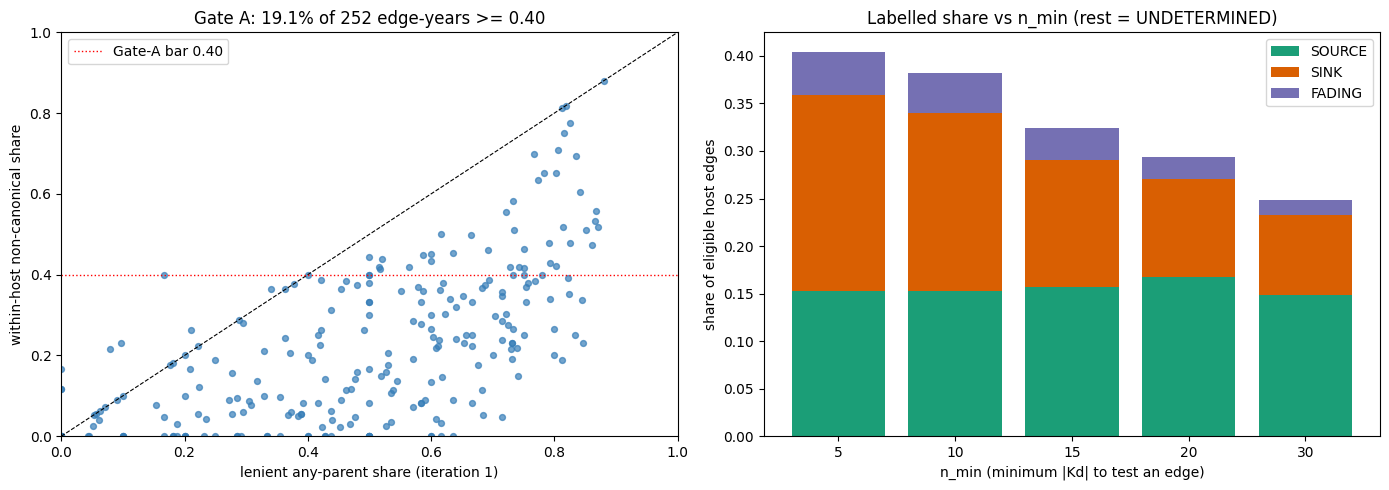

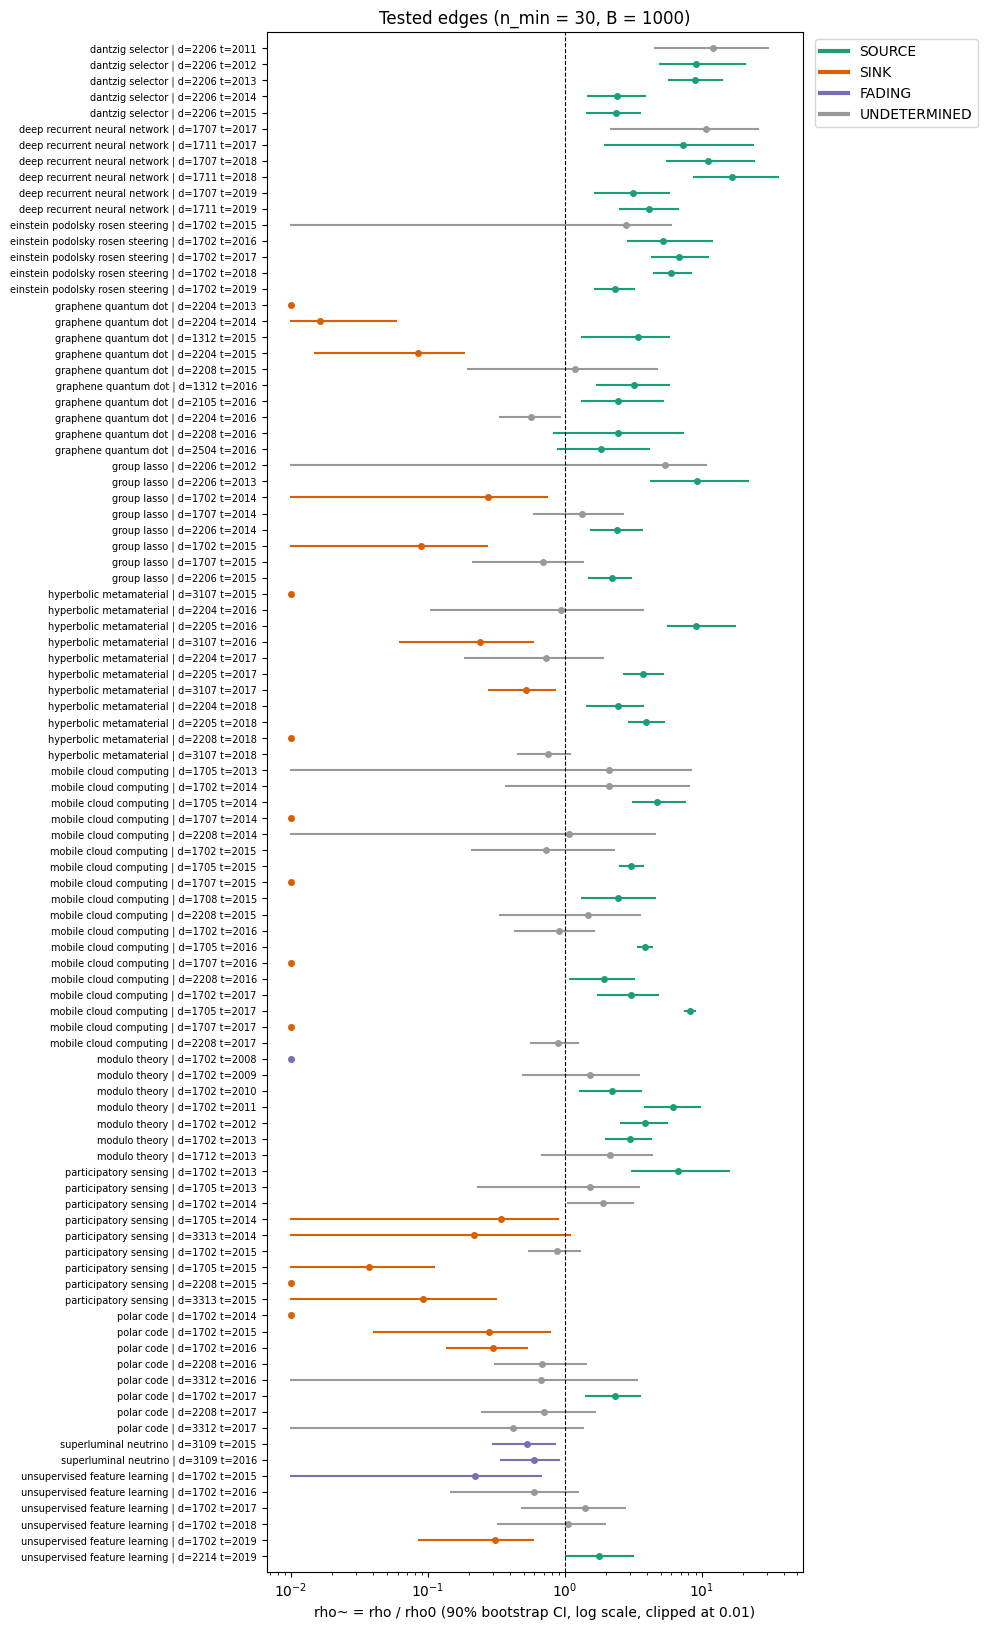

In [20]:
ga = pd.read_parquet(RESULTS / "gate_a" / "gate_a_host_edges.parquet")
vs = ga[ga.n_children >= 10]
colors = {"SOURCE": "#1b9e77", "SINK": "#d95f02", "FADING": "#7570b3", "UNDETERMINED": "#999999"}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
a = ax[0]
a.scatter(vs.lenient_share, vs.within_host_share, s=18, alpha=.7, c="#377eb8")
a.plot([0, 1], [0, 1], "k--", lw=.8)
a.axhline(0.40, color="red", lw=1, ls=":", label="Gate-A bar 0.40")
a.set_xlabel("lenient any-parent share (iteration 1)")
a.set_ylabel("within-host non-canonical share")
a.set_title(f"Gate A: {verdict['share_edges_ge_040']:.1%} of {len(vs)} edge-years >= 0.40")
a.set_xlim(0, 1); a.set_ylim(0, 1); a.legend(loc="upper left")

a = ax[1]
sh = pd.DataFrame({k: v[f"state_nmin{k}"].value_counts(normalize=True) for k in NMIN_BINS}).T.fillna(0)
bottom = np.zeros(len(sh))
for s in ["SOURCE", "SINK", "FADING"]:
    if s in sh:
        a.bar([str(k) for k in sh.index], sh[s], bottom=bottom, color=colors[s], label=s)
        bottom += sh[s].to_numpy()
a.set_xlabel("n_min (minimum |Kd| to test an edge)")
a.set_ylabel("share of eligible host edges")
a.set_title("Labelled share vs n_min (rest = UNDETERMINED)")
a.legend()
plt.tight_layout()
plt.show()

# forest plot of rho~ for every tested edge (values clipped at 0.01 so rho~ = 0 stays visible on the log axis)
tt = tested.reset_index(drop=True)
fig, a = plt.subplots(figsize=(10, 0.16 * len(tt) + 1.2))
clip = lambda x: np.clip(x, 0.01, None)
for i, r in tt.iterrows():
    a.plot([clip(r.rho_tilde_lo), clip(r.rho_tilde_hi)], [i, i], color=colors[r.state_main], lw=1.5)
    a.plot(clip(r.rho_tilde), i, "o", color=colors[r.state_main], ms=4)
a.axvline(1, color="k", lw=.8, ls="--")
a.set_xscale("log")
a.set_yticks(range(len(tt)))
a.set_yticklabels([f"{p} | d={d} t={t}" for p, d, t in zip(tt.phrase, tt.d, tt.t)], fontsize=7)
a.set_ylim(-1, len(tt))
a.invert_yaxis()
a.set_xlabel("rho~ = rho / rho0 (90% bootstrap CI, log scale, clipped at 0.01)")
a.set_title(f"Tested edges (n_min = {int(v.n_min_main.iloc[0])}, B = {B})")
for s, c in colors.items():
    a.plot([], [], color=c, lw=3, label=s)
a.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()